# Complete Seaborn Tutorial

Seaborn is a statistical data visualization library built on top of Matplotlib. It provides:
- **Beautiful default styles** and color palettes
- **Statistical estimation** and error bars automatically
- **High-level functions** for complex plots (pair plots, heatmaps, facet grids)
- **Integration** with Pandas DataFrames
- **Built-in datasets** for practice

This tutorial covers everything from basic distribution plots to advanced multi-plot grids.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and defaults
sns.set_theme(style='darkgrid', palette='viridis')
# Or use: sns.set(style='whitegrid', font_scale=1.2)

# For notebook
%matplotlib inline

# Load built-in datasets
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')
flights = sns.load_dataset('flights')

np.random.seed(42)

## 1. Distribution Plots

Visualize the distribution of single or multiple variables.

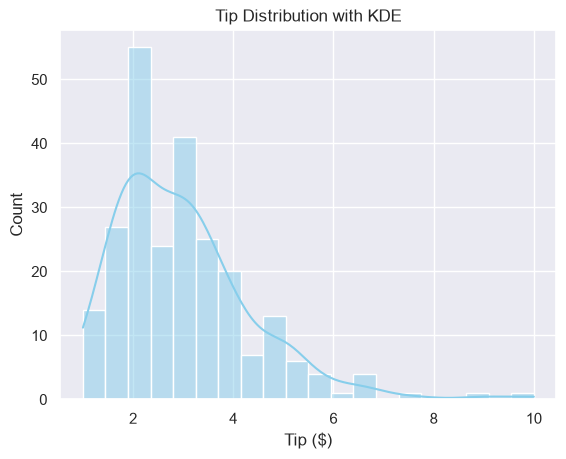

In [2]:
# Histogram (histplot)
sns.histplot(tips['tip'], bins=20, kde=True, color='skyblue')
plt.title('Tip Distribution with KDE')
plt.xlabel('Tip ($)')
plt.show()

In [3]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
tips['time'].unique()

['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']

In [6]:
tips['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

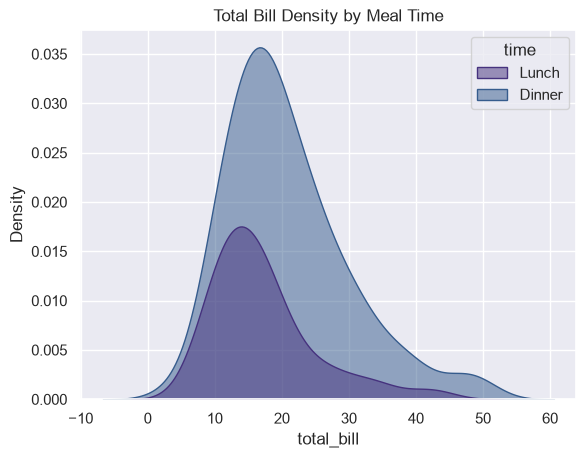

In [10]:
# Kernel Density Estimate (KDE) plot
sns.kdeplot(data=tips, x='total_bill', hue='time', fill=True, alpha=0.5)
plt.title('Total Bill Density by Meal Time')
plt.show()

In [12]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


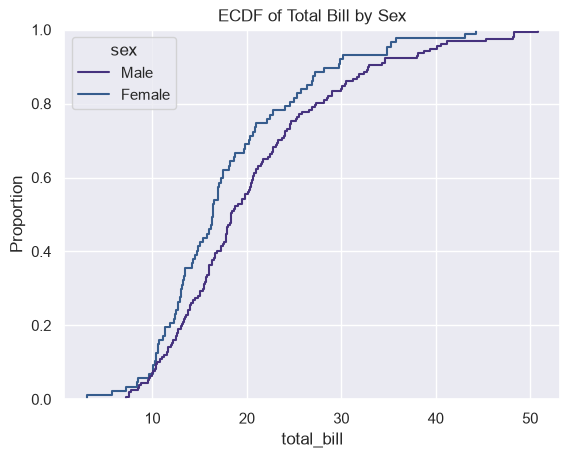

In [11]:
# ECDF (Empirical Cumulative Distribution Function)
sns.ecdfplot(data=tips, x='total_bill', hue='sex')
plt.title('ECDF of Total Bill by Sex')
plt.show()

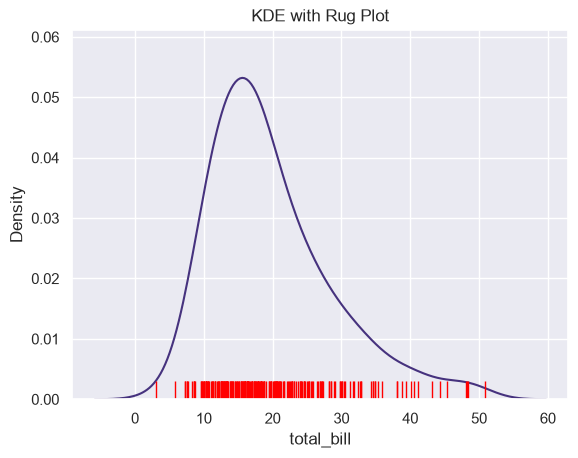

In [13]:
# Rug plot (shows individual data points along axis)
sns.kdeplot(data=tips, x='total_bill')
sns.rugplot(data=tips, x='total_bill', color='red', height=0.05)
plt.title('KDE with Rug Plot')
plt.show()

## 2. Categorical / Relational Plots

Plot categorical vs numeric variables.

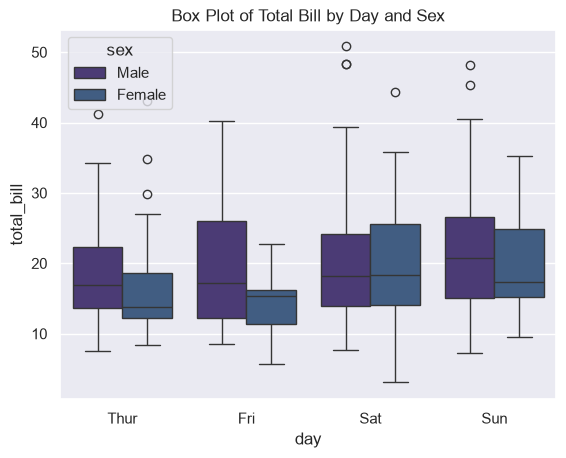

In [14]:
# Box plot
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex')
plt.title('Box Plot of Total Bill by Day and Sex')
plt.show()

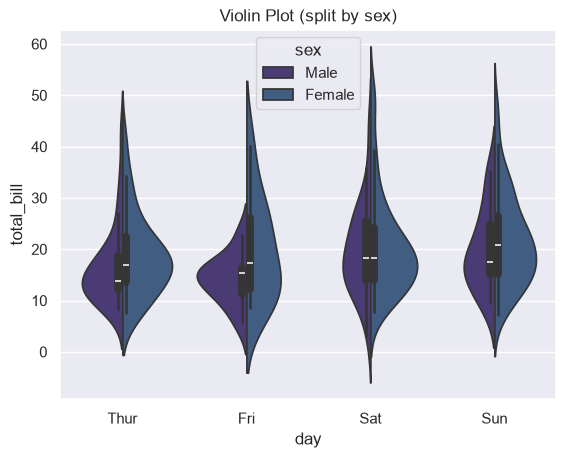

In [19]:
# Violin plot (box + KDE)
sns.violinplot(data=tips, x='day', y='total_bill',hue='sex',split=True)
plt.title('Violin Plot (split by sex)')
plt.show()

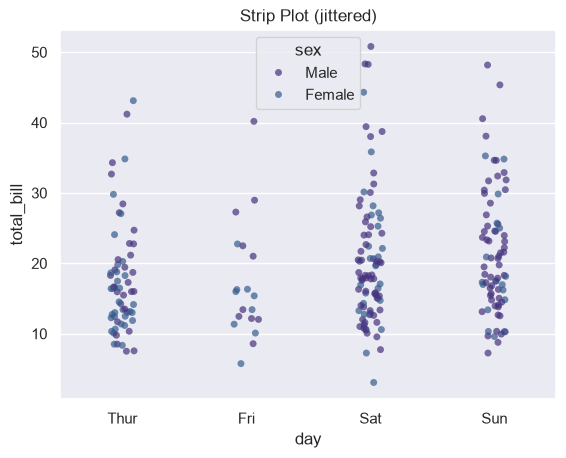

In [20]:
# Strip plot (jittered points)
sns.stripplot(data=tips, x='day', y='total_bill', hue='sex', jitter=True, alpha=0.7)
plt.title('Strip Plot (jittered)')
plt.show()

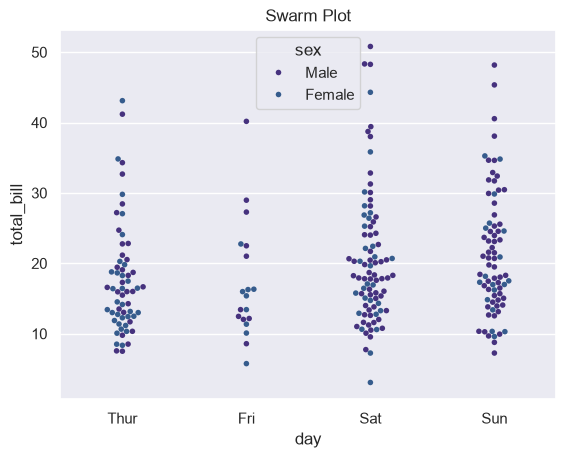

In [21]:
# Swarm plot (points adjusted to avoid overlap)
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', size=4)
plt.title('Swarm Plot')
plt.show()

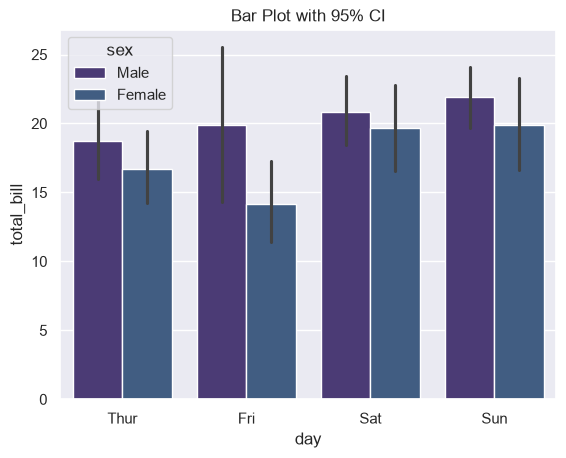

In [22]:
# Bar plot (with confidence intervals)
sns.barplot(data=tips, x='day', y='total_bill', hue='sex', errorbar=('ci', 95))
plt.title('Bar Plot with 95% CI')
plt.show()

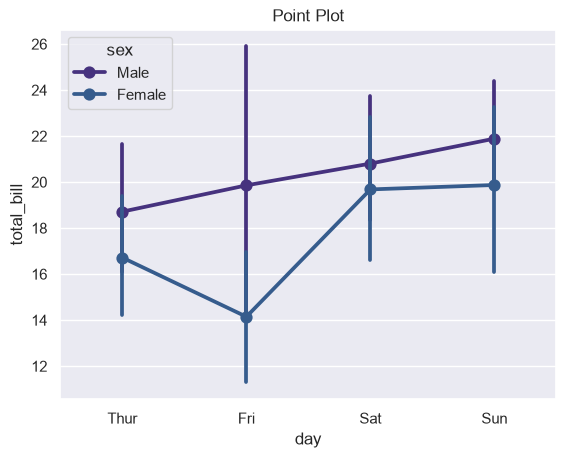

In [23]:
# Point plot (line + CI)
sns.pointplot(data=tips, x='day', y='total_bill', hue='sex', markers='o', linestyle='-')
plt.title('Point Plot')
plt.show()

## 3. Regression Plots

Visualize relationships with linear regression.

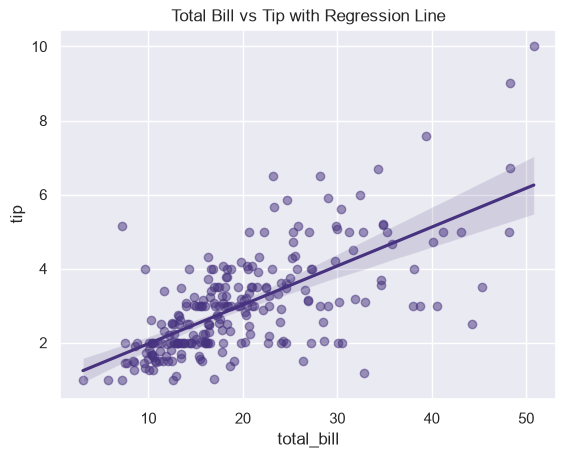

In [24]:
# Linear regression with confidence band
sns.regplot(data=tips, x='total_bill', y='tip', ci=95, scatter_kws={'alpha':0.5})
plt.title('Total Bill vs Tip with Regression Line')
plt.show()

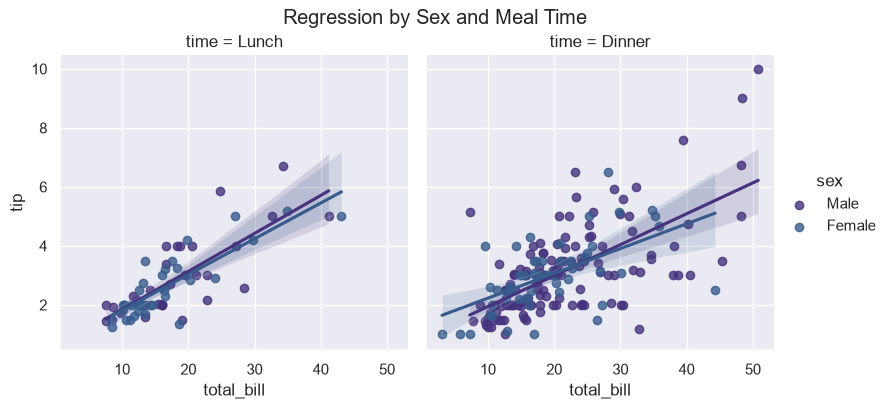

In [25]:
# lmplot with grouping
sns.lmplot(data=tips, x='total_bill', y='tip', hue='sex', col='time', height=4, aspect=1)
plt.suptitle('Regression by Sex and Meal Time', y=1.02)
plt.show()

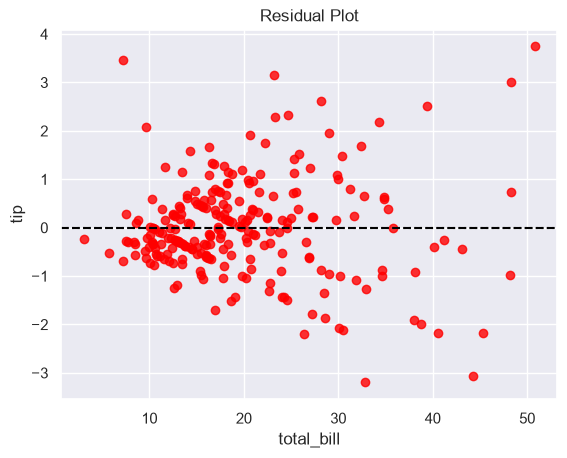

In [26]:
# Residual plot
sns.residplot(data=tips, x='total_bill', y='tip', color='red')
plt.title('Residual Plot')
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

## 4. Matrix / Heatmap Plots

Visualize correlations or pivot tables.

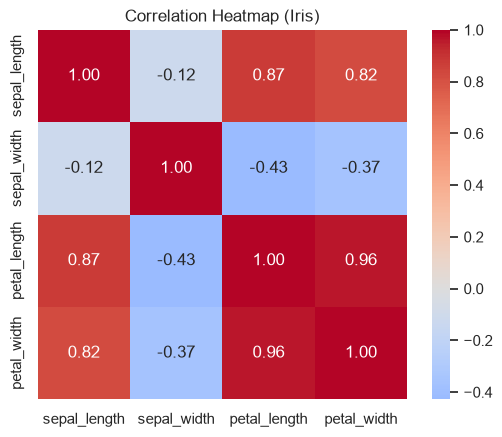

In [27]:
# Correlation heatmap
corr = iris.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Heatmap (Iris)')
plt.show()

In [32]:
# Cluster map (heatmap with hierarchical clustering)
sns.clustermap(iris.drop('species', axis=1), standard_scale=1, cmap='viridis', figsize=(8, 8))
plt.show()

RuntimeError: clustermap requires scipy to be available

In [33]:
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [36]:
flights_pivot

0
1
2
3
4
...
139
140
141
142
143


In [38]:
flights.pivot?

Signature: flights.pivot(*, columns, index=<no_default>, values=<no_default>) -> 'DataFrame'
Docstring:
Return reshaped DataFrame organized by given index / column values.

Reshape data (produce a "pivot" table) based on column values. Uses
unique values from specified `index` / `columns` to form axes of the
resulting DataFrame. This function does not support data
aggregation, multiple values will result in a MultiIndex in the
columns. See the :ref:`User Guide <reshaping>` for more on reshaping.

Parameters
----------
columns : Hashable or a sequence of the previous
    Column to use to make new frame's columns.
index : Hashable or a sequence of the previous, optional
    Column to use to make new frame's index. If not given, uses existing index.
values : Hashable or a sequence of the previous, optional
    Column(s) to use for populating new frame's values. If not
    specified, all remaining columns will be used and the result will
    have hierarchically indexed columns.

Returns
--

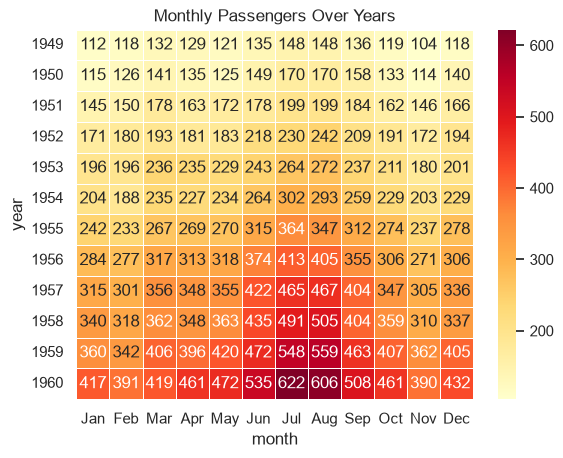

In [41]:
# Pivot table heatmap (flights dataset)
flights_pivot = flights.pivot(index='year', columns='month', values='passengers')
sns.heatmap(flights_pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Monthly Passengers Over Years')
plt.show()

## 5. Multi‑Plot Grids

Create grids of related plots with `FacetGrid`, `PairGrid`, etc.

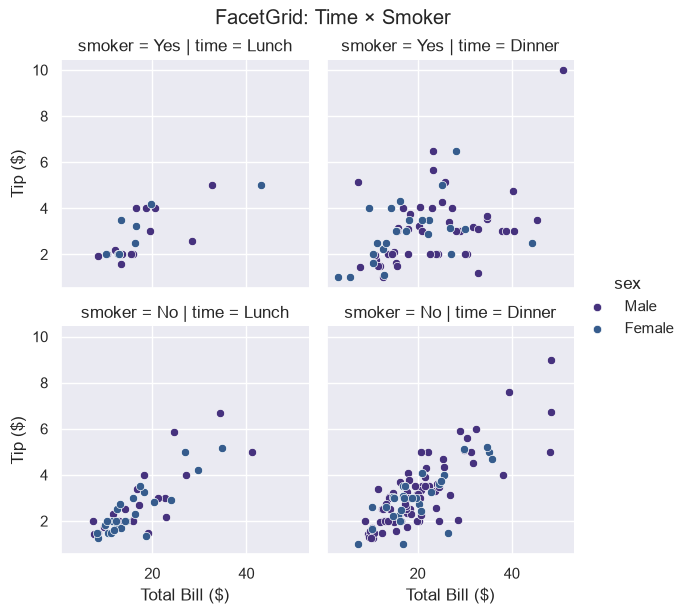

In [42]:
# FacetGrid – create a grid of plots based on categorical variables
g = sns.FacetGrid(tips, col='time', row='smoker', hue='sex', height=3)
g.map(sns.scatterplot, 'total_bill', 'tip')
g.add_legend()
g.set_axis_labels('Total Bill ($)', 'Tip ($)')
plt.suptitle('FacetGrid: Time × Smoker', y=1.02)
plt.show()

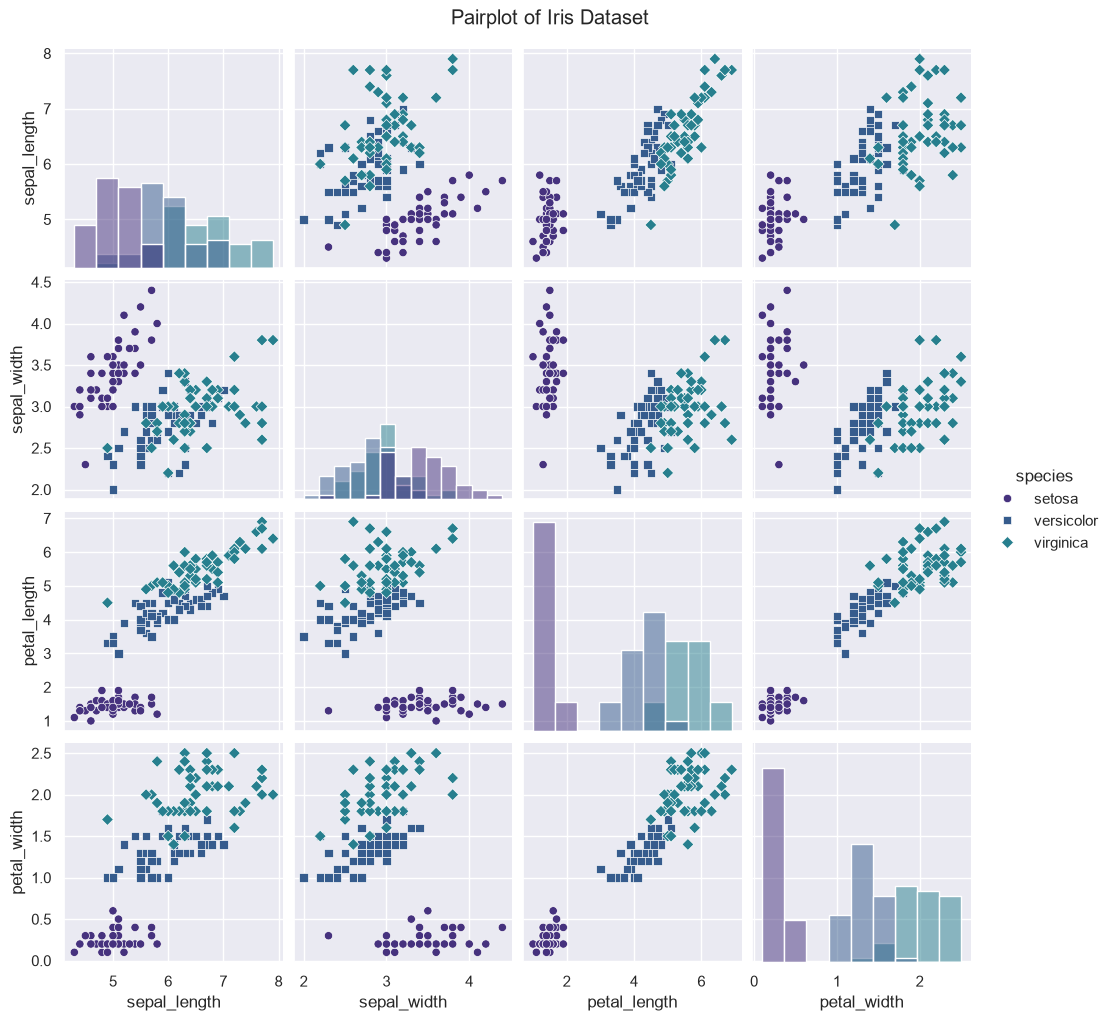

In [43]:
# Pairplot – pairwise relationships in a dataset
sns.pairplot(iris, hue='species', diag_kind='hist', markers=['o', 's', 'D'], height=2.5)
plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()

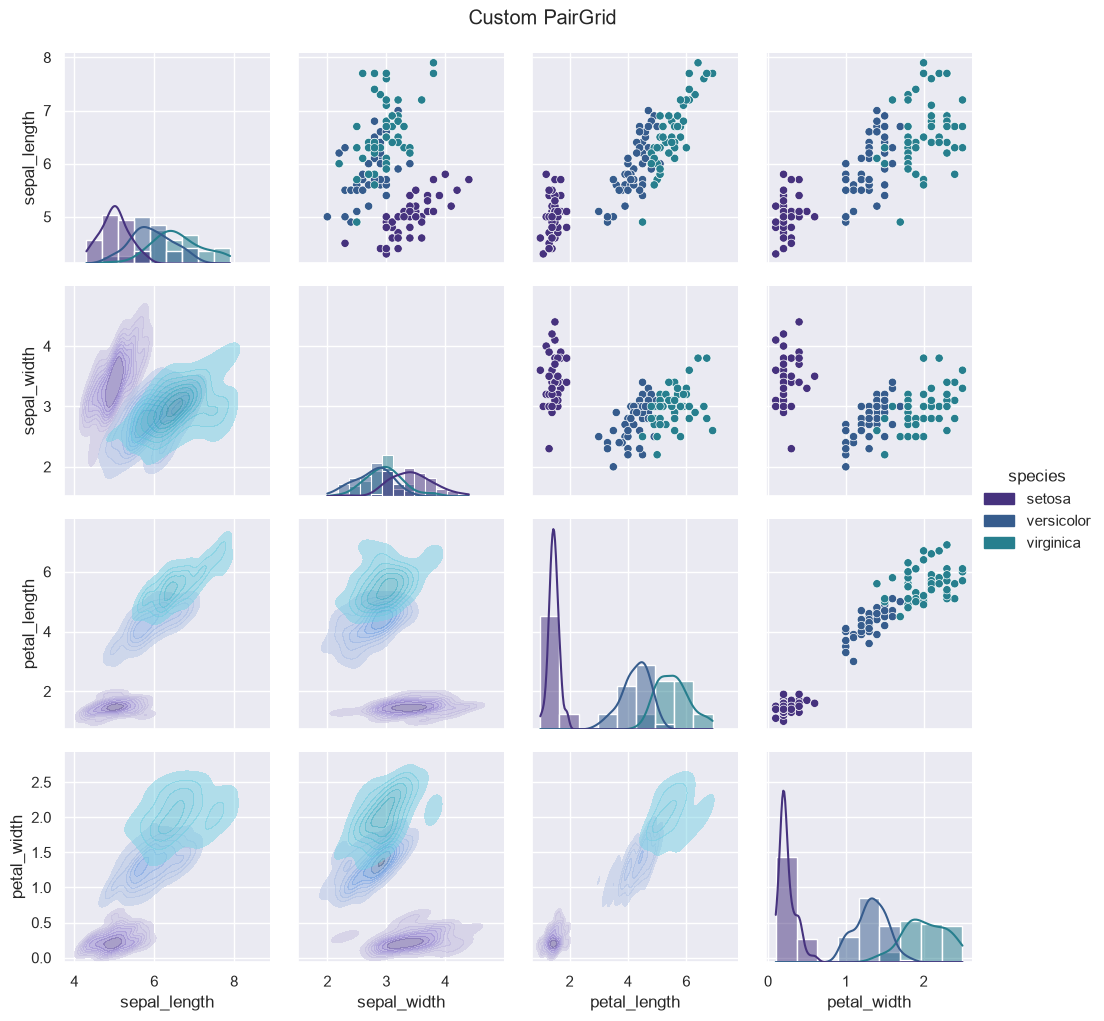

In [44]:
# PairGrid – more control than pairplot
g = sns.PairGrid(iris, hue='species')
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot, fill=True, alpha=0.5)
g.map_diag(sns.histplot, kde=True)
g.add_legend()
plt.suptitle('Custom PairGrid', y=1.02)
plt.show()

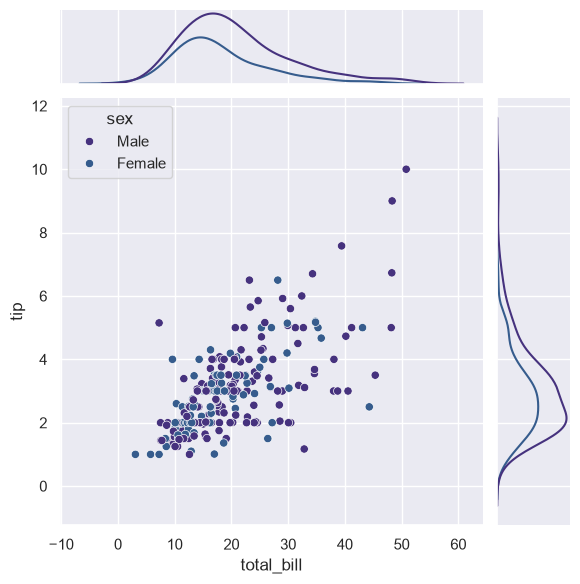

In [46]:
# JointGrid – bivariate + marginals
g = sns.JointGrid(data=tips, x='total_bill', y='tip', hue='sex')
g.plot(sns.scatterplot, sns.kdeplot)
plt.show()

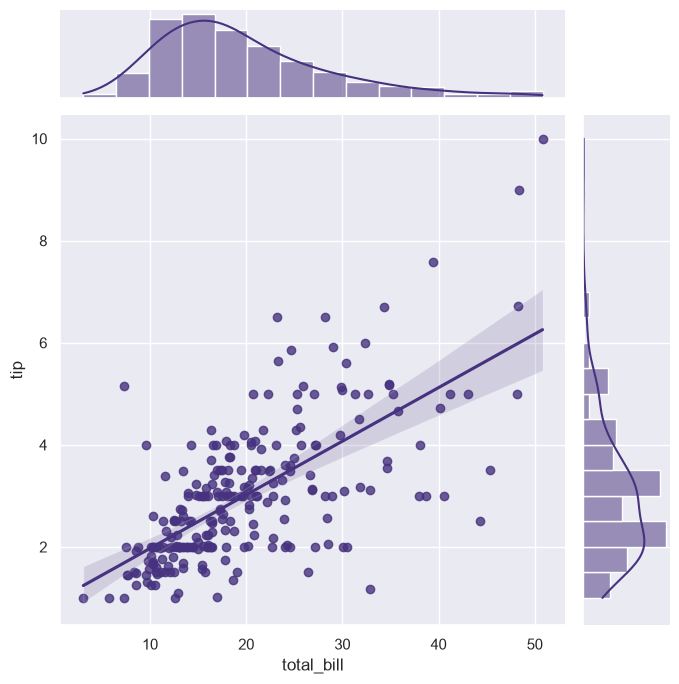

In [50]:
# JointPlot – quick version of JointGrid
sns.jointplot(data=tips, x='total_bill', y='tip',  kind='reg', height=7)# hue='sex'
plt.show()

## 6. Customization: Themes and Color Palettes

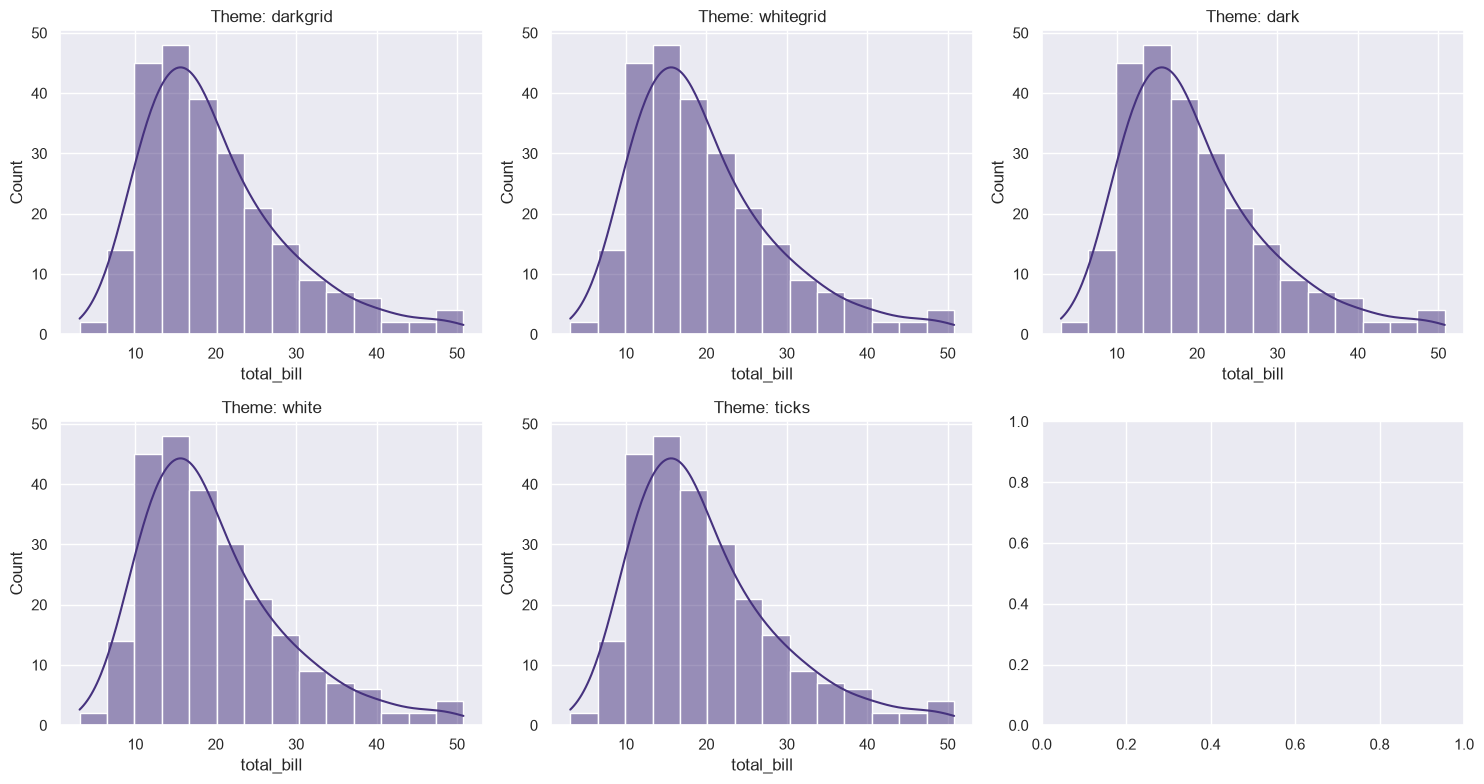

In [54]:
# Available themes: 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
themes = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

for ax, theme in zip(axes.flatten(), themes):
    sns.set_theme(style=theme)
    sns.histplot(tips['total_bill'], ax=ax, kde=True)
    ax.set_title(f'Theme: {theme}')

plt.tight_layout()
plt.show()

# Reset to default
sns.set_theme(style='darkgrid')

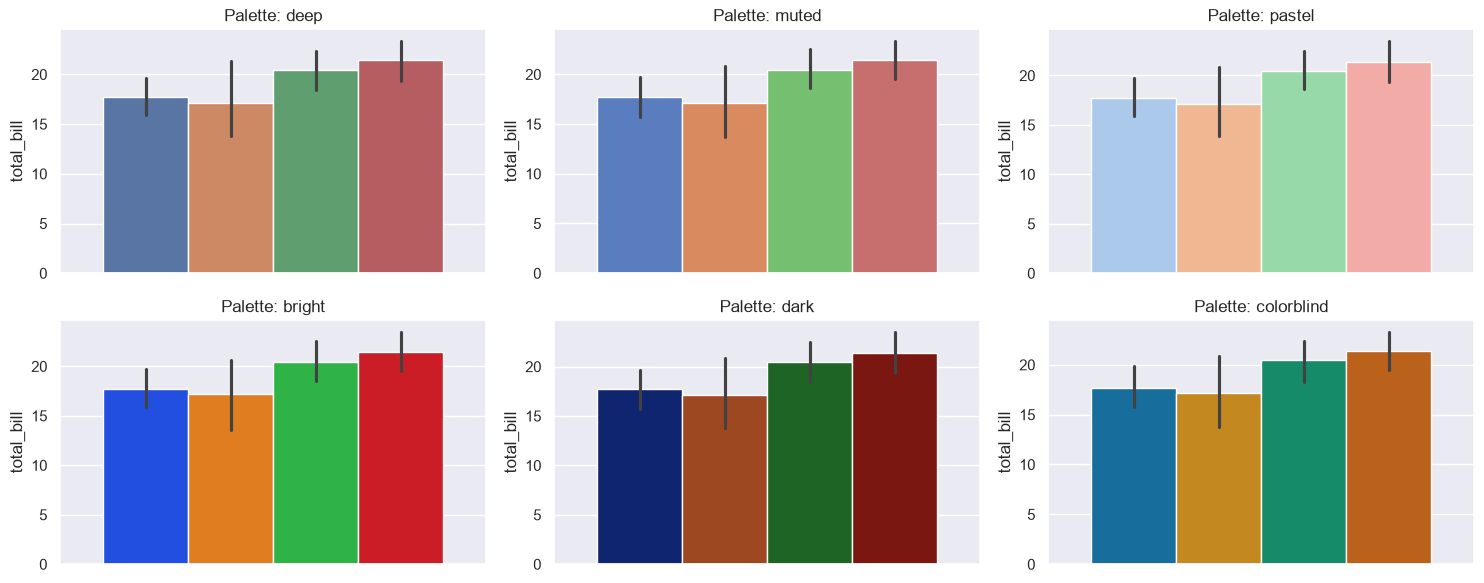

In [53]:
# Color palettes: qualitative, sequential, diverging
palettes = ['deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind']

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax, palette in zip(axes.flatten(), palettes):
    sns.barplot(data=tips, hue='day', y='total_bill', palette=palette, ax=ax,legend = False)
    ax.set_title(f'Palette: {palette}')
plt.tight_layout()
plt.show()

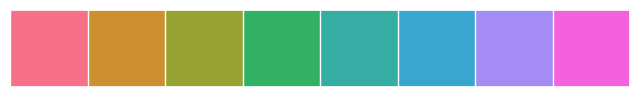

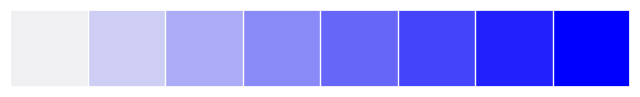

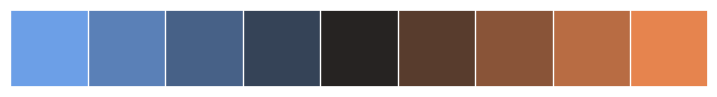

In [55]:
# Create custom palette
custom = sns.color_palette('husl', 8)
sns.palplot(custom)
plt.show()

# Sequential color map
sns.palplot(sns.light_palette('blue', 8))
plt.show()

# Diverging color map
sns.palplot(sns.diverging_palette(250, 30, l=65, center='dark', n=9))
plt.show()

## 7. Plot Context (Scaling)

Adjust the scale of plot elements (labels, lines, markers).

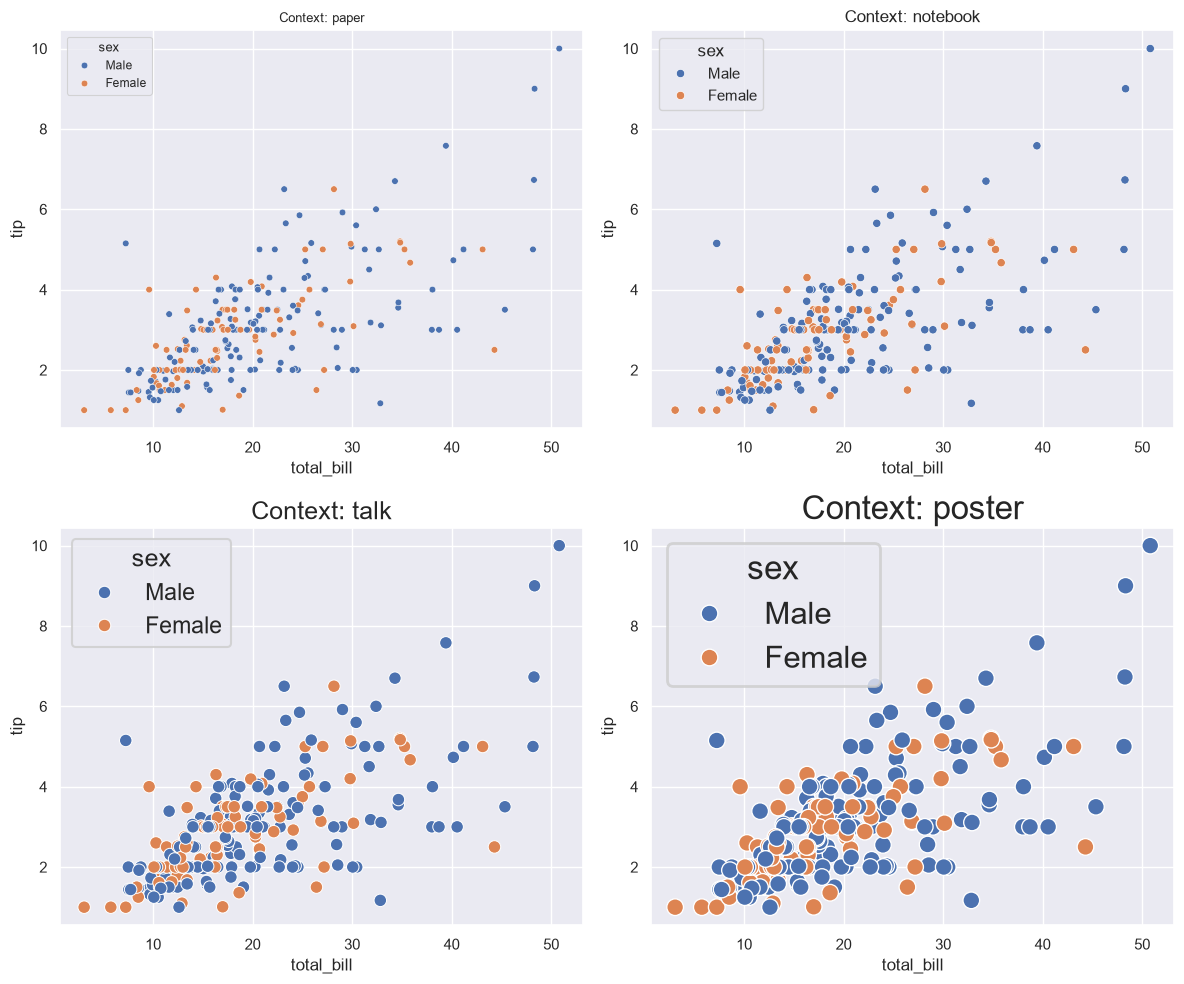

In [56]:
# Contexts: 'paper', 'notebook', 'talk', 'poster'
contexts = ['paper', 'notebook', 'talk', 'poster']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, context in zip(axes.flatten(), contexts):
    with sns.plotting_context(context):
        sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', ax=ax)
        ax.set_title(f'Context: {context}')
plt.tight_layout()
plt.show()

## 8. Built‑in Datasets

Seaborn comes with several datasets for practice: `tips`, `iris`, `titanic`, `flights`, `mpg`, `penguins`, `diamonds`, etc.

In [57]:
# List available datasets
import seaborn as sns
print("Available datasets:", sns.get_dataset_names())

# Load penguins dataset (modern alternative to iris)
penguins = sns.load_dataset('penguins')
print("\nPenguins dataset shape:", penguins.shape)

Available datasets: ['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']

Penguins dataset shape: (344, 7)


In [ ]:
# Example with penguins
sns.pairplot(penguins.dropna(), hue='species', height=2.5)
plt.suptitle('Penguins Pairplot', y=1.02)
plt.show()

## 9. Statistical Estimation and Error Bars

Seaborn automatically includes confidence intervals and statistical tests in many plots.

In [ ]:
# Bootstrapped confidence intervals
sns.barplot(data=tips, x='day', y='tip', errorbar=('ci', 95), capsize=0.2)
plt.title('Bar Plot with Bootstrapped 95% CI')
plt.show()

# Changing error bar type
sns.barplot(data=tips, x='day', y='tip', errorbar='sd', capsize=0.2)
plt.title('Bar Plot with Standard Deviation')
plt.show()

In [ ]:
# Box plot with test annotation (requires statannotations package, not built-in)
# But seaborn's violin/box show distributions clearly

## 10. `catplot` – Unified Categorical Plotting

`catplot` provides a unified interface to all categorical plot types with faceting.

In [ ]:
# Different kinds: 'strip', 'swarm', 'box', 'violin', 'boxen', 'point', 'bar', 'count'
sns.catplot(data=tips, x='day', y='total_bill', hue='sex', kind='violin', split=True, height=5)
plt.title('catplot with violin')
plt.show()

# Count plot
sns.catplot(data=tips, x='day', kind='count', hue='sex', height=5)
plt.title('Count Plot')
plt.show()

## 11. `relplot` – Unified Relational Plotting

`relplot` combines scatter and line plots with faceting.

In [ ]:
# Scatter with relplot
sns.relplot(data=tips, x='total_bill', y='tip', hue='sex', col='time', row='smoker', height=3)
plt.suptitle('relplot (scatter)', y=1.02)
plt.show()

# Line plot with relplot
flights_small = flights[flights['year'].isin([1949, 1950, 1951])]
sns.relplot(data=flights_small, x='month', y='passengers', hue='year', kind='line', marker='o', height=5)
plt.title('Passenger Trend by Month')
plt.show()

## 12. `displot` – Unified Distribution Plotting

Combines histplot, kdeplot, ecdfplot with faceting.

In [ ]:
# Histogram with KDE and faceting
sns.displot(data=tips, x='total_bill', kind='hist', kde=True, col='time', height=4)
plt.suptitle('Distribution by Meal Time', y=1.02)
plt.show()

# ECDF with faceting
sns.displot(data=tips, x='total_bill', kind='ecdf', hue='sex', col='time', height=4)
plt.suptitle('ECDF by Sex and Time', y=1.02)
plt.show()

## 13. Advanced Topics

- **`sns.mpl` integration**: combine Seaborn with Matplotlib for fine control
- **`sns.axes_style()` / `sns.set_style()`**: temporary style context
- **`sns.despine()`**: remove top/right spines
- **`sns.set_context()`**: temporary scaling
- **`sns.set_palette()`**: set default palette
- **`sns.color_palette()` as a context manager**

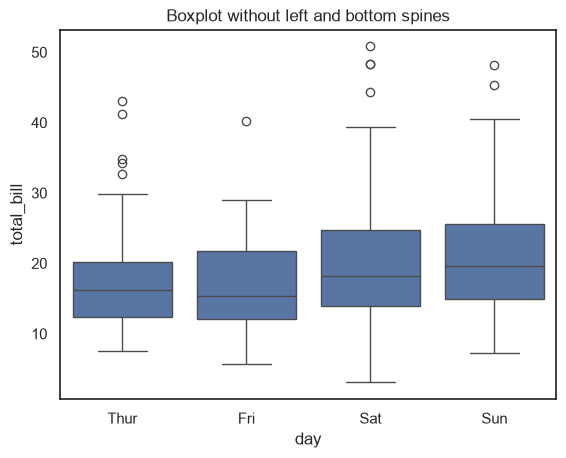

In [62]:
# Remove spines
with sns.axes_style('white'):
    sns.boxplot(data=tips, x='day', y='total_bill')
    sns.despine(left=False, bottom=False,right =False,top=False)
    plt.title('Boxplot without left and bottom spines')
plt.show()

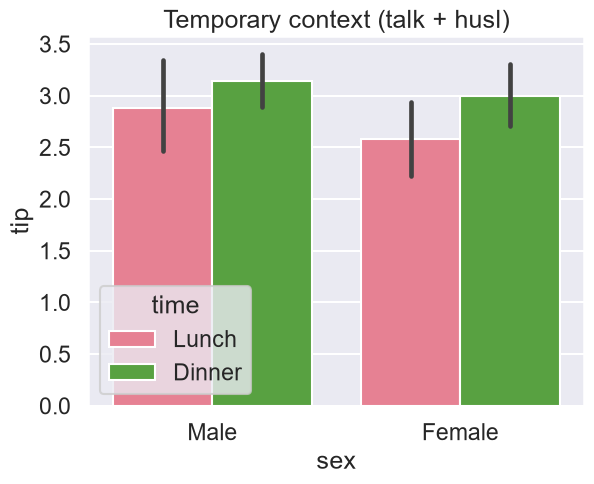

Original style: {'axes.facecolor': '#EAEAF2', 'axes.edgecolor': 'white', 'axes.grid': True, 'axes.axisbelow': True, 'axes.labelcolor': '.15', 'figure.facecolor': 'white', 'grid.color': 'white', 'grid.linestyle': '-', 'text.color': '.15', 'xtick.color': '.15', 'ytick.color': '.15', 'xtick.direction': 'out', 'ytick.direction': 'out', 'lines.solid_capstyle': <CapStyle.round: 'round'>, 'patch.edgecolor': 'w', 'patch.force_edgecolor': True, 'image.cmap': 'rocket', 'font.family': ['sans-serif'], 'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'], 'xtick.bottom': False, 'xtick.top': False, 'ytick.left': False, 'ytick.right': False, 'axes.spines.left': True, 'axes.spines.bottom': True, 'axes.spines.right': True, 'axes.spines.top': True}


In [63]:
# Temporary style and palette
with sns.plotting_context('talk'), sns.color_palette('husl', 3):
    sns.barplot(data=tips, x='sex', y='tip', hue='time')
    plt.title('Temporary context (talk + husl)')
plt.show()

# Check that original style is restored
print("Original style:", sns.axes_style())

## 14. Performance Tips for Large Datasets

- Use `rasterized=True` in scatter plots
- Use `hexbin` via `sns.jointplot(kind='hex')`
- Downsample data before plotting
- Use `linewidth=0` for dense scatter
- For `kdeplot`, increase `bw_method` or reduce `n_levels`

In [ ]:
# Hexbin joint plot for large data
large_data = pd.DataFrame({'x': np.random.randn(10000), 'y': np.random.randn(10000) * 2})
sns.jointplot(data=large_data, x='x', y='y', kind='hex', gridsize=50, color='purple')
plt.suptitle('Hexbin Jointplot (efficient for large data)', y=1.02)
plt.show()

## Summary

You have now covered:
- **Distribution plots**: histplot, kdeplot, ecdfplot, rugplot
- **Categorical plots**: boxplot, violinplot, stripplot, swarmplot, barplot, pointplot, countplot
- **Regression plots**: regplot, lmplot, residplot
- **Matrix plots**: heatmap, clustermap
- **Multi-plot grids**: FacetGrid, PairGrid, JointGrid, pairplot, jointplot
- **Customization**: themes, color palettes, contexts
- **Unified plotting functions**: catplot, relplot, displot
- **Statistical estimation**: error bars (CI, SD), bootstrapping
- **Built-in datasets**: tips, iris, titanic, flights, penguins
- **Advanced styling**: despine, temporary contexts, palette management
- **Performance**: hexbin, rasterization, downsampling

Seaborn makes statistical visualization both beautiful and easy. Combine it with Matplotlib for publication‑ready figures.